# EDA - programm_summury.csv

## Chargement et inspection initiale

#### Objectif
Charger les fichiers du dataset **600K+ Fitness Exercise & Workout Program Dataset** et obtenir une première vue d’ensemble :

- dimensions de chaque fichier (lignes / colonnes) ;
- aperçu des premières lignes (cohérence des champs) ;
- typage des variables et complétude (valeurs manquantes) ;
- présence éventuelle de doublons ;
- liste complète des colonnes disponibles.

Cette étape valide que le corpus est exploitable avant nettoyage et préparation NLP pour le projet **TrAIn.me**.


#### Interprétation attendue
À l’issue de cette première inspection, on commentera :

- la taille du dataset (volume “exercice” vs volume “programmes”) ;
- la nature des variables : textes (title/description), catégories (level/goal/equipment), structure (week/day), paramètres d’entraînement (sets/reps/intensity), métadonnées (timestamps) ;
- la présence de valeurs manquantes et leur ordre de grandeur ;
- l’existence (ou non) de doublons stricts ;
- la cohérence générale des premières lignes (valeurs lisibles, structure logique, champs textuels non vides).

Ce diagnostic sert de référence avant les étapes de nettoyage, normalisation et structuration pour le Deep Learning / NLP.


### Importation des librairies essentielles

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import textwrap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import kagglehub
import prince

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
from pathlib import Path
import sys

root = Path.cwd()           # ex: .../DuckDB/eda/life_style_data
themes_root = None

for p in [root, *root.parents]:   # remonte: life_style_data -> eda -> DuckDB -> ...
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence (il doit exister un dossier 'themes/' quelque part au-dessus)."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['dataset_fusion', 'eda', 'model_training', 'preprocessing', 'themes', '__init__.py', '__pycache__']


### Configuration d'affichage pour plus de lisibilité

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

### Thème “TrAIn.me”
Il applique un fond dark propre, une grille discrète, des ticks lisibles, et une palette bleus/cians cohérente.

In [4]:
# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
# Booléen de contrôle : True = thème TrAIn.me (dark), False = style clair "ticks"
USE_DARK_THEME = True  # modifie ici selon le contexte

# Activer le thème au début du notebook :
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Chargement du dataset

In [5]:
# Téléchargement du dataset depuis Kaggle
# Identifiant Kaggle attendu : "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
dataset_path = kagglehub.dataset_download("adnanelouardi/600k-fitness-exercise-and-workout-program-dataset")
print("Dataset téléchargé dans :", dataset_path)

# Recherche des CSV disponibles
csv_files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".csv")])
print("Fichiers CSV trouvés :", csv_files)

# On cible explicitement les deux fichiers décrits dans la page Kaggle
path_programs = os.path.join(dataset_path, "program_summary.csv")

# Chargement
df = pd.read_csv(path_programs)

print("Chargement terminé.")
print(f"program_summary.csv   : {df.shape[0]:,} lignes | {df.shape[1]} colonnes")


Dataset téléchargé dans : C:\Users\fback\.cache\kagglehub\datasets\adnanelouardi\600k-fitness-exercise-and-workout-program-dataset\versions\1
Fichiers CSV trouvés : ['program_summary.csv', 'programs_detailed_boostcamp_kaggle.csv']
Chargement terminé.
program_summary.csv   : 2,598 lignes | 10 colonnes


### Aperçu général des premières lignes

In [6]:
display(df.head())

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit
0,(MASS MONSTER) High Intensity 4 Day Upper Lowe...,Build tones of muscular with this high intensi...,['Intermediate'],"['Muscle & Sculpting', 'Bodyweight Fitness']",Full Gym,12.0,90.0,384,2024-01-20 10:23:00,2025-06-29 12:39:00
1,(NOT MY PROGRAM)SHJ Jotaro,Build strength and size,"['Advanced', 'Intermediate']",['Bodybuilding'],Full Gym,8.0,60.0,224,2024-07-08 02:28:00,2025-06-18 09:15:00
2,1 PowerLift Per Day Powerbuilding 5 Day Bro Split,Based off of Andy Baker's KCS (Kingwood Streng...,"['Beginner', 'Novice', 'Intermediate']","['Athletics', 'Powerlifting', 'Powerbuilding']",Full Gym,6.0,90.0,237,2025-04-23 09:21:00,2025-06-18 11:55:00
3,10 Week Mass Building Program,This workout is designed to increase your musc...,"['Intermediate', 'Advanced']",['Powerbuilding'],Garage Gym,10.0,70.0,280,2024-09-07 03:44:00,2025-06-18 08:01:00
4,10 week deadlift focus,Increase deadlift,"['Intermediate', 'Advanced']","['Powerbuilding', 'Powerlifting', 'Bodybuildin...",Full Gym,10.0,80.0,356,2024-12-23 03:13:00,2025-06-18 12:19:00


### Informations générales sur le typage et la complétude

In [7]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             2598 non-null   object 
 1   description       2594 non-null   object 
 2   level             2598 non-null   object 
 3   goal              2598 non-null   object 
 4   equipment         2597 non-null   object 
 5   program_length    2597 non-null   float64
 6   time_per_workout  2598 non-null   float64
 7   total_exercises   2598 non-null   int64  
 8   created           2597 non-null   object 
 9   last_edit         2596 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 203.1+ KB


### Statistiques descriptives des variables numériques

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
program_length,2597.0,8.812476,4.185403,1.0,5.0,8.0,12.00,18.0
time_per_workout,2598.0,69.035412,24.394798,10.0,60.0,60.0,90.00,180.0
total_exercises,2598.0,232.884142,208.123873,1.0,108.0,192.5,307.75,5040.0


### Analyse des valeurs manquantes et doublons

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("\n--- Valeurs manquantes par colonne (top 10) ---")
display(missing_values.head(10))

print(f"\nNombre total de doublons détectés : {duplicates}")


--- Valeurs manquantes par colonne (top 10) ---


description         4
last_edit           2
equipment           1
program_length      1
created             1
title               0
level               0
goal                0
time_per_workout    0
total_exercises     0
dtype: int64


Nombre total de doublons détectés : 0


### Liste complète des colonnes disponibles

In [10]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())


--- Liste des colonnes du dataset ---
['title', 'description', 'level', 'goal', 'equipment', 'program_length', 'time_per_workout', 'total_exercises', 'created', 'last_edit']


## Statistiques descriptives et distribution des variables

#### Objectif
Obtenir une vue d’ensemble chiffrée des variables numériques du dataset **program_summary.csv** :

- résumer la distribution des variables disponibles (durée du programme, durée par séance, volume total d’exercices) ;
- repérer les ordres de grandeur, la dispersion et les éventuelles valeurs extrêmes ;
- préparer l’identification d’outliers et la sélection de variables pertinentes pour la suite de l’analyse.


#### Interprétation attendue
À l’issue de cette section, l’interprétation devra mettre en évidence :

- les valeurs centrales des variables clés (durée typique des programmes, temps moyen par séance, volume global d’exercices) ;
- la dispersion (écarts-types, min/max, quartiles) afin d’identifier des programmes “courts” vs “longs”, et des programmes “légers” vs “très volumineux” ;
- la présence éventuelle de valeurs extrêmes ou atypiques (ex. volume d’exercices très élevé) pouvant nécessiter un traitement spécifique ;
- les premières tendances structurantes utiles pour le projet **TrAIn.me** (plages réalistes à cibler lors de la génération de programmes).


### Activation du thème TrAIn.me

In [11]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


## Statistiques descriptives globales

In [12]:
# --- Colonnes numériques disponibles ---
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques détectées ({len(num_cols)}) : {num_cols}")

# Statistiques descriptives de base
if num_cols:
    stats_num = df[num_cols].describe().T
    display(stats_num)
else:
    print("Aucune variable numérique détectée.")
    
# Quelques repères métier (si les colonnes existent)
if "program_length" in df.columns:
    print(f"\nDurée moyenne du programme (semaines) : {df['program_length'].mean():.2f}")

if "time_per_workout" in df.columns:
    print(f"Temps moyen par séance (minutes) : {df['time_per_workout'].mean():.2f}")

if "total_exercises" in df.columns:
    print(f"Nombre total moyen d’exercices par programme : {df['total_exercises'].mean():.2f}")


Variables numériques détectées (3) : ['program_length', 'time_per_workout', 'total_exercises']


,count,mean,std,min,25%,50%,75%,max
program_length,2597.0,8.812476,4.185403,1.0,5.0,8.0,12.00,18.0
time_per_workout,2598.0,69.035412,24.394798,10.0,60.0,60.0,90.00,180.0
total_exercises,2598.0,232.884142,208.123873,1.0,108.0,192.5,307.75,5040.0



Durée moyenne du programme (semaines) : 8.81
Temps moyen par séance (minutes) : 69.04
Nombre total moyen d’exercices par programme : 232.88


### Distribution des variables clés


Variables numériques représentées : ['program_length', 'time_per_workout', 'total_exercises']


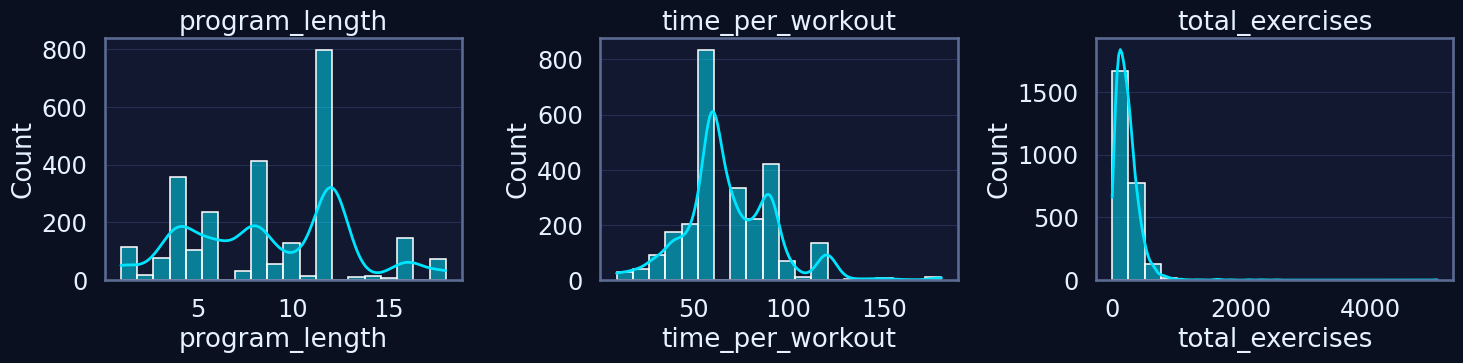

In [13]:
# Variables numériques pertinentes (ici : toutes sont métier)
num_vars = list(num_cols)
print(f"Variables numériques représentées : {num_vars}")

n = len(num_vars)
if n == 0:
    print("Aucune variable numérique pertinente à visualiser.")
else:
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col].dropna(), bins=20, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots pour repérer les outliers

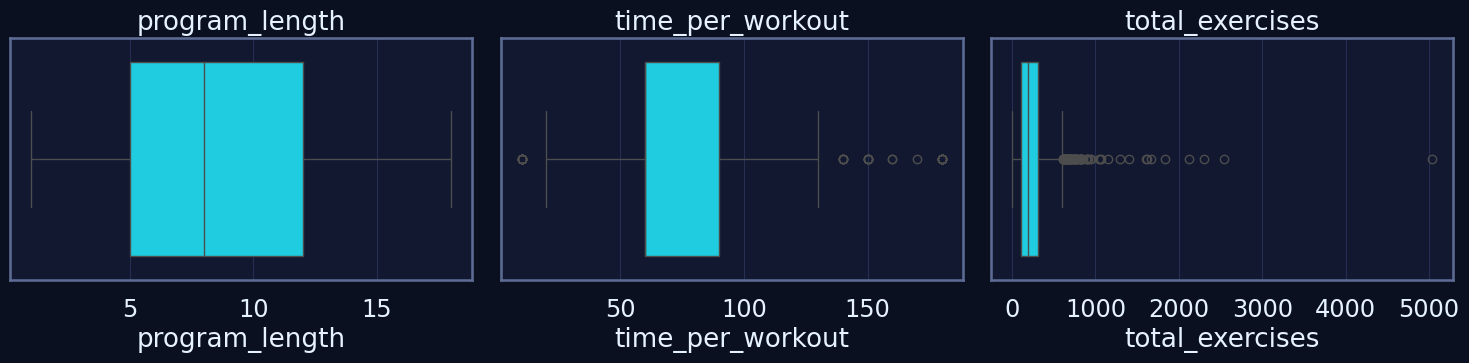

In [14]:
if num_vars:
    plt.figure(figsize=(5 * len(num_vars), 4))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(1, len(num_vars), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()
else:
    print("Aucun boxplot pertinent à afficher (pas de variable numérique métier).")


### Statistiques descriptives enrichies

In [15]:
if num_cols:
    desc = df[num_cols].describe().T
    desc["missing_%"] = df[num_cols].isna().mean() * 100
    desc["zeros_%"] = (df[num_cols] == 0).mean() * 100
    desc["skew"] = df[num_cols].skew(numeric_only=True)
    desc["kurt"] = df[num_cols].kurt(numeric_only=True)

    display(desc.sort_values("std", ascending=False))
else:
    print("Aucune variable numérique disponible pour des statistiques enrichies.")


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
total_exercises,2598.0,232.884142,208.123873,1.0,108.0,192.5,307.75,5040.0,0.000000,0.0,7.099139,125.265230
time_per_workout,2598.0,69.035412,24.394798,10.0,60.0,60.0,90.00,180.0,0.000000,0.0,0.727516,2.039627
program_length,2597.0,8.812476,4.185403,1.0,5.0,8.0,12.00,18.0,0.038491,0.0,0.084756,-0.733091


### Détection rapide d'outliers (IQR)

In [16]:
iqr_report = {}

for col in num_cols:
    s = df[col].dropna()
    if s.empty:
        iqr_report[col] = 0
        continue

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])
display(iqr_df.sort_values("outliers", ascending=False))


,outliers
total_exercises,85
time_per_workout,58
program_length,0


### Aperçu corrélations (sous-ensemble lisible)

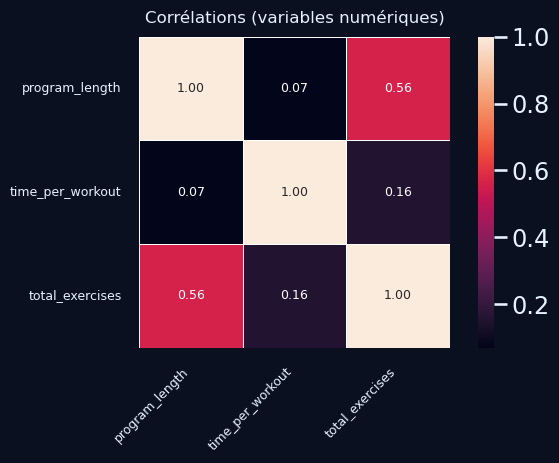

In [17]:
if len(num_cols) >= 2:
    subset_cols = num_cols  # peu de colonnes → heatmap lisible
    corr = df[subset_cols].corr(numeric_only=True)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
        linewidths=0.5,
        annot_kws={"size": 9},
    )
    plt.title("Corrélations (variables numériques)", fontsize=12, pad=10)
    plt.xticks(fontsize=9, rotation=45, ha="right")
    plt.yticks(fontsize=9, rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Corrélation non pertinente : une seule variable numérique disponible.")


## Visualisation univariée

#### Objectif
Compléter les statistiques descriptives par une analyse visuelle des distributions des variables numériques du dataset **program_summary.csv**.

L’objectif est de :
- visualiser la forme des distributions (centrage, dispersion, asymétrie) ;
- repérer visuellement d’éventuelles valeurs extrêmes (outliers) ;
- confirmer les plages réalistes des variables structurantes (durée, temps par séance, volume d’exercices),
afin de cadrer les futures étapes de préparation et de génération de programmes pour **TrAIn.me**.


#### Interprétation attendue
À l’issue de cette section, l’analyse devra :
- décrire la distribution des variables numériques (formes dominantes, valeurs typiques) ;
- identifier les variables potentiellement asymétriques (ex. “total_exercises” souvent très étalée) ;
- signaler les points extrêmes susceptibles de perturber l’entraînement (programmes anormalement longs / volumineux) ;
- proposer des pistes de traitement pour la suite (cap, clipping, filtrage, ou pondération) si nécessaire.


### Sélection robuste des variables numériques à visualiser

In [18]:
# Colonnes numériques
num_cols = df.select_dtypes(include="number").columns.tolist()

# Filtre de robustesse : au moins 90% de valeurs non-nulles
min_non_null_ratio = 0.90
robust_num_cols = [
    c for c in num_cols
    if df[c].notna().mean() >= min_non_null_ratio
]

# Exclusion éventuelle d'identifiants techniques (si présents dans d'autres datasets)
excluded = {"id", "program_id", "parent_id"}
robust_num_cols = [c for c in robust_num_cols if c not in excluded]

print(f"Variables numériques détectées : {num_cols}")
print(f"Variables numériques retenues (robustes) : {robust_num_cols}")


Variables numériques détectées : ['program_length', 'time_per_workout', 'total_exercises']
Variables numériques retenues (robustes) : ['program_length', 'time_per_workout', 'total_exercises']


### Visualisation des distributions univariées (hist + KDE)

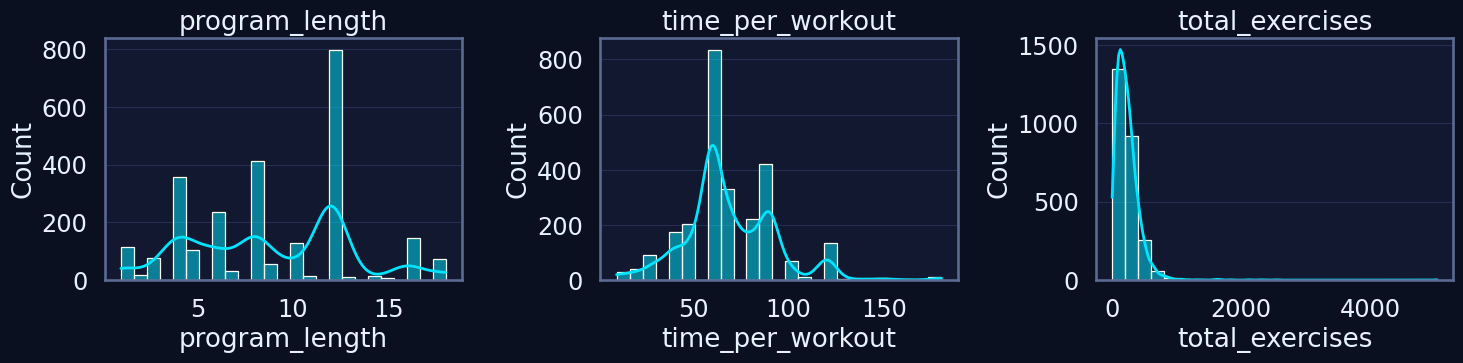

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

if not robust_num_cols:
    print("Aucune variable numérique robuste à visualiser.")
else:
    n = len(robust_num_cols)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(robust_num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col].dropna(), bins=25, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots univariés pour détection visuelle d'outliers

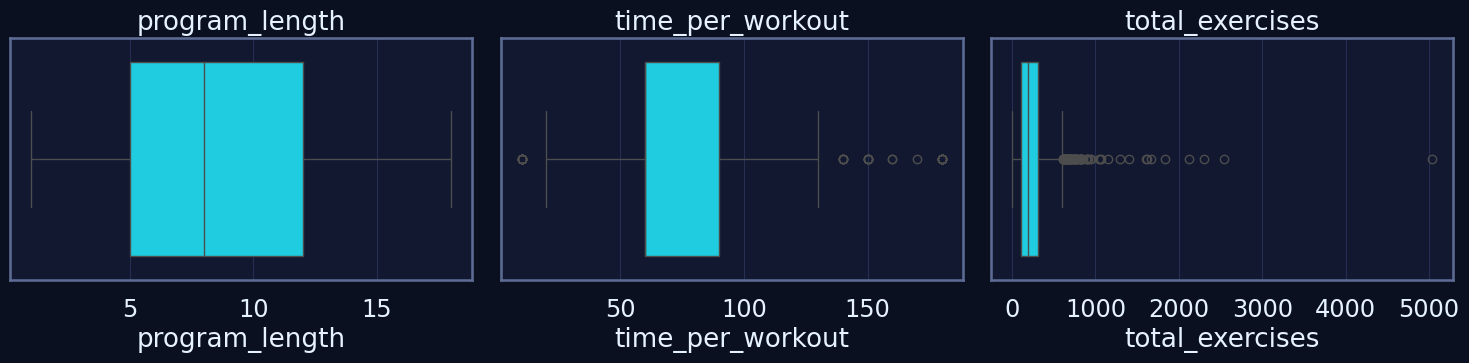

In [20]:
if not robust_num_cols:
    print("Aucun boxplot à afficher.")
else:
    plt.figure(figsize=(5 * len(robust_num_cols), 4))

    for i, col in enumerate(robust_num_cols, 1):
        plt.subplot(1, len(robust_num_cols), i)
        sns.boxplot(x=df[col].dropna())
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## Visualisation bivariée

#### Objectif
Analyser les relations entre variables **catégorielles** (equipment, level, goal) et **numériques**
(program_length, time_per_workout, total_exercises), ainsi que les co-occurrences entre catégories.

Cette étape vise à :
- identifier les catégories associées à des programmes plus longs, plus intenses ou plus volumineux ;
- comprendre les combinaisons fréquentes (niveau ↔ objectifs, équipement ↔ objectifs) ;
- préparer des règles métier et des contraintes de génération pour TrAIn.me.


#### Interprétation attendue
L’analyse devra mettre en évidence :
- les différences de distributions numériques selon l’équipement, le niveau et/ou l’objectif ;
- les associations fréquentes entre catégories (ex. certains goals très liés à un niveau ou à un équipement) ;
- d’éventuels déséquilibres (catégories très dominantes) pouvant biaiser l’apprentissage ;
- des pistes de normalisation (top-N catégories, regroupement, pondération).


### Relations catégorielles ↔ numérique

In [21]:
# Colonnes attendues côté program_summary
num_cols = [c for c in ["program_length", "time_per_workout", "total_exercises"] if c in df.columns]
cat_cols = [c for c in ["equipment", "level", "goal"] if c in df.columns]

print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)

# On limite l'affichage aux catégories les plus fréquentes pour garder des graphes lisibles
TOP_N = 10
top_equipment = df["equipment"].value_counts(dropna=False).head(TOP_N).index.tolist() if "equipment" in df else []
df_top = df[df["equipment"].isin(top_equipment)].copy() if top_equipment else df.copy()

display(df_top[["equipment"] + num_cols].groupby("equipment")[num_cols].median().sort_values(num_cols[0], ascending=False) if "equipment" in df_top and num_cols else df_top.head())


Numériques : ['program_length', 'time_per_workout', 'total_exercises']
Catégorielles : ['equipment', 'level', 'goal']


,program_length,time_per_workout,total_exercises
equipment,,,
At Home,10.0,50.0,144.0
Full Gym,9.0,70.0,218.5
Dumbbell Only,8.0,50.0,144.0
Garage Gym,8.0,60.0,140.0


### Boxplots : numérique par catégorie

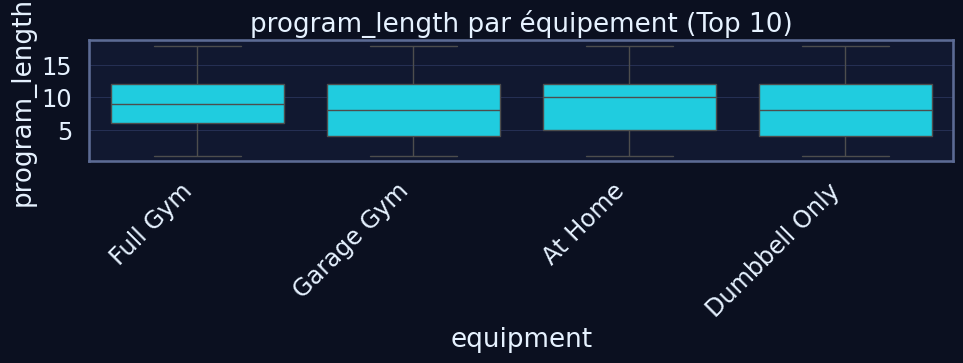

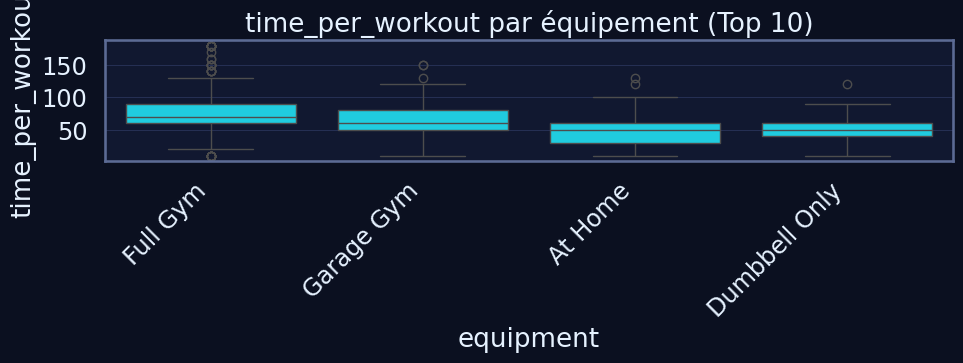

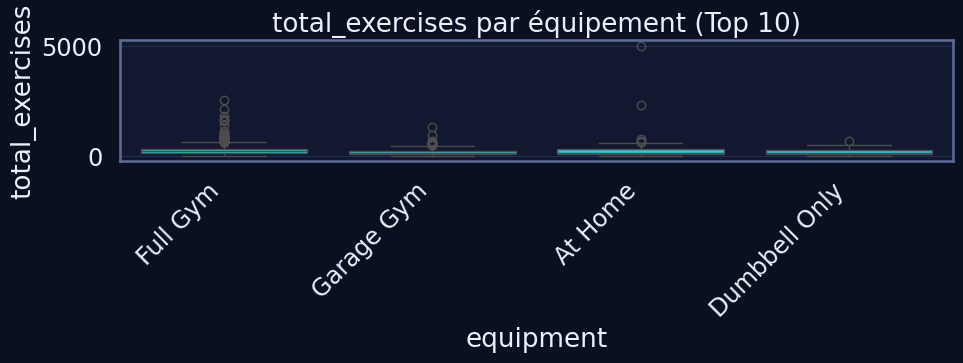

In [22]:
if "equipment" in df_top.columns and num_cols:
    for metric in num_cols:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df_top, x="equipment", y=metric)
        plt.title(f"{metric} par équipement (Top {TOP_N})")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, axis="y")
        plt.tight_layout()
        plt.show()
else:
    print("Impossible d'afficher les boxplots : colonnes manquantes ou pas de variables numériques.")


### Co-occurrences entre catégories (crosstab + heatmaps)

In [23]:
import ast

def safe_parse_list(x):
    """Convertit "['A','B']" -> ['A','B'] ; sinon renvoie [] si NaN/erreur."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else [v]
    except Exception:
        return [s] if s else []

df_cat = df.copy()

if "level" in df_cat.columns:
    df_cat["level_list"] = df_cat["level"].apply(safe_parse_list)
else:
    df_cat["level_list"] = [[]] * len(df_cat)

if "goal" in df_cat.columns:
    df_cat["goal_list"] = df_cat["goal"].apply(safe_parse_list)
else:
    df_cat["goal_list"] = [[]] * len(df_cat)

# Explode level puis goal
df_expl = df_cat.explode("level_list").explode("goal_list").copy()
df_expl = df_expl.rename(columns={"level_list": "level_item", "goal_list": "goal_item"})

# Filtre top catégories pour lisibilité
TOP_LEVEL = 8
TOP_GOAL = 12

top_levels = df_expl["level_item"].value_counts().head(TOP_LEVEL).index.tolist()
top_goals  = df_expl["goal_item"].value_counts().head(TOP_GOAL).index.tolist()

df_heat = df_expl[df_expl["level_item"].isin(top_levels) & df_expl["goal_item"].isin(top_goals)].copy()

ct = pd.crosstab(df_heat["level_item"], df_heat["goal_item"])
display(ct)


goal_item,Athletics,Bodybuilding,Bodyweight Fitness,Muscle & Sculpting,Olympic Weightlifting,Powerbuilding,Powerlifting
level_item,,,,,,,
Advanced,186,620,111,322,26,365,205
Beginner,210,437,142,286,8,199,122
Intermediate,397,1307,218,716,28,760,383
Novice,271,862,171,498,14,454,248


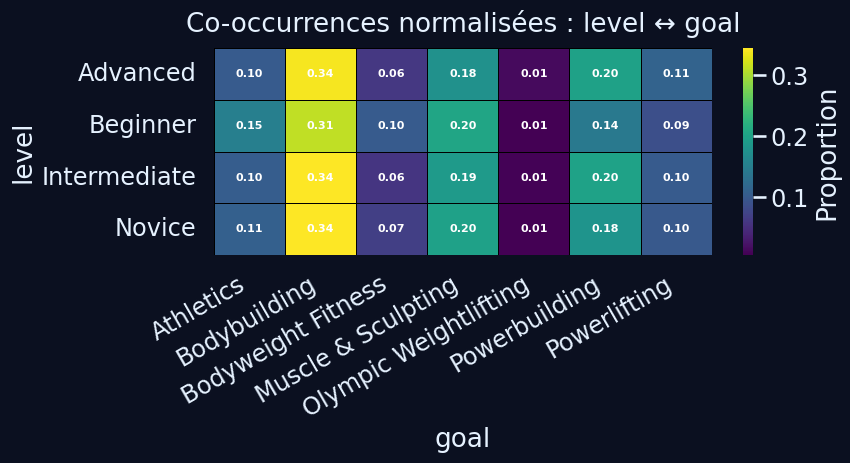

In [24]:
if not ct.empty:
    ct_norm = ct.div(ct.sum(axis=1), axis=0)

    plt.figure(figsize=(9, 5))  # hauteur augmentée (clé ici)
    ax = sns.heatmap(
        ct_norm,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=0.4,
        linecolor="black",
        cbar_kws={"label": "Proportion"},
        annot_kws={
            "size": 8,
            "color": "white",
            "weight": "bold"
        }
    )

    ax.set_aspect("auto")  # très important : laisse respirer les lignes

    ax.set_title("Co-occurrences normalisées : level ↔ goal", pad=12)
    ax.set_xlabel("goal")
    ax.set_ylabel("level")

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()


### Comptage empilé (stacked) : composition d’un champ au sein du Top Equipment

level_item,Advanced,Beginner,Intermediate,Novice
equipment,,,,
At Home,27,31,88,61
Dumbbell Only,14,20,48,36
Full Gym,604,550,1359,919
Garage Gym,203,136,418,267


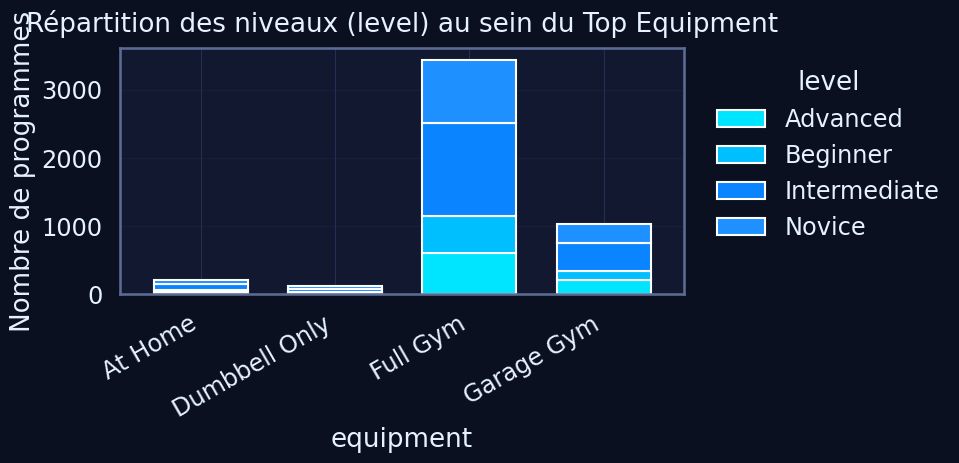

In [25]:
if "equipment" in df.columns and "level" in df.columns:
    df_stack = df.copy()
    df_stack["level_item"] = df_stack["level"].apply(safe_parse_list)
    df_stack = df_stack.explode("level_item")

    TOP_N = 4  # tu peux ajuster si besoin
    top_equipment = df_stack["equipment"].value_counts().head(TOP_N).index.tolist()
    top_levels = df_stack["level_item"].value_counts().head(4).index.tolist()

    df_stack = df_stack[
        df_stack["equipment"].isin(top_equipment)
        & df_stack["level_item"].isin(top_levels)
    ]

    stack_ct = pd.crosstab(df_stack["equipment"], df_stack["level_item"])
    display(stack_ct)

    # --- Plot ---
    ax = stack_ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),      #  + hauteur
        width=0.7             #  barres plus épaisses
    )

    ax.set_title(
        "Répartition des niveaux (level) au sein du Top Equipment",
        pad=12
    )
    ax.set_xlabel("equipment")
    ax.set_ylabel("Nombre de programmes")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=30,
        ha="right"
    )

    # Grille légère
    ax.grid(True, axis="y", alpha=0.3)

    # Légende propre
    ax.legend(
        title="level",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()

else:
    print("Colonnes manquantes pour le stacked plot (equipment/level).")


### Comptage empilé (stacked) : composition d’un champ au sein du Top Goal

goal_item,Athletics,Bodybuilding,Muscle & Sculpting,Powerbuilding,Powerlifting
equipment,,,,,
At Home,23,84,46,34,16
Dumbbell Only,13,41,19,21,15
Full Gym,384,1214,663,669,355
Garage Gym,118,384,207,181,108


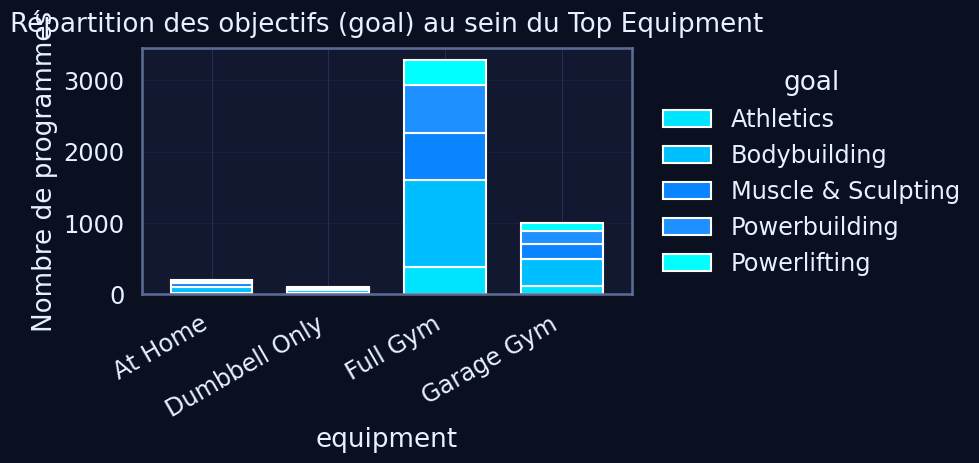

In [26]:
if "equipment" in df.columns and "goal" in df.columns:
    df_stack = df.copy()
    df_stack["goal_item"] = df_stack["goal"].apply(safe_parse_list)
    df_stack = df_stack.explode("goal_item")

    TOP_N_EQUIP = 4
    TOP_N_GOAL = 5

    top_equipment = (
        df_stack["equipment"]
        .value_counts()
        .head(TOP_N_EQUIP)
        .index
        .tolist()
    )

    top_goals = (
        df_stack["goal_item"]
        .value_counts()
        .head(TOP_N_GOAL)
        .index
        .tolist()
    )

    df_stack = df_stack[
        df_stack["equipment"].isin(top_equipment)
        & df_stack["goal_item"].isin(top_goals)
    ]

    stack_ct = pd.crosstab(df_stack["equipment"], df_stack["goal_item"])
    display(stack_ct)

    # --- Plot ---
    ax = stack_ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),   # + hauteur
        width=0.7          # barres épaisses
    )

    ax.set_title(
        "Répartition des objectifs (goal) au sein du Top Equipment",
        pad=12
    )
    ax.set_xlabel("equipment")
    ax.set_ylabel("Nombre de programmes")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=30,
        ha="right"
    )

    ax.grid(True, axis="y", alpha=0.3)

    ax.legend(
        title="goal",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()

else:
    print("Colonnes manquantes pour le stacked plot (equipment/goal).")


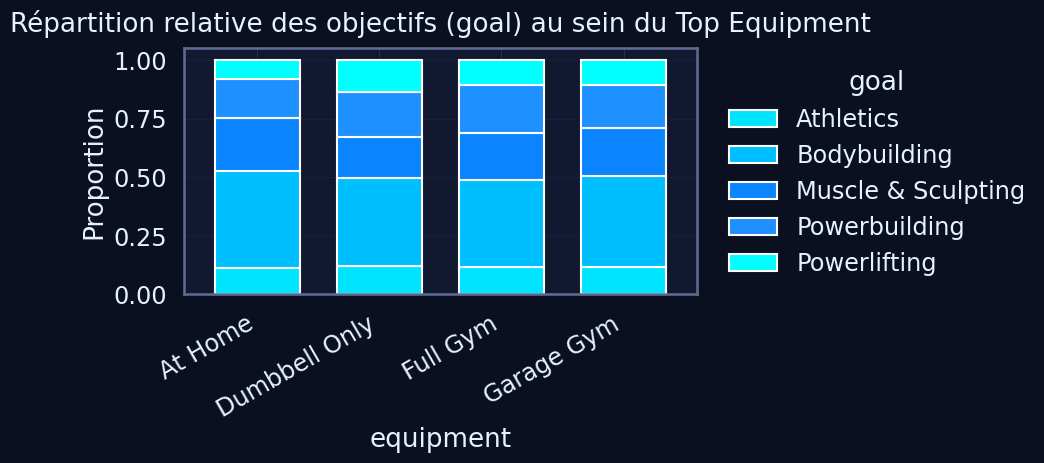

In [27]:
stack_pct = stack_ct.div(stack_ct.sum(axis=1), axis=0)

ax = stack_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    width=0.7
)

ax.set_title(
    "Répartition relative des objectifs (goal) au sein du Top Equipment",
    pad=12
)
ax.set_ylabel("Proportion")
ax.set_xlabel("equipment")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.legend(
    title="goal",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Analyse multivariée (ACM)

#### Objectif
Réaliser une Analyse des Correspondances Multiples (ACM / MCA) sur les variables catégorielles du dataset
(program_summary.csv) afin de :

- visualiser les proximités entre catégories (ex. objectifs, niveaux, équipements) ;
- identifier des “profils” de programmes (combinaisons typiques de modalités) ;
- repérer des regroupements structurants utiles pour cadrer la génération de programmes dans TrAIn.me.


#### Interprétation attendue
À l’issue de cette analyse, on attend :

- une estimation de la variance expliquée par les premières dimensions ;
- une lecture des axes (Dim1/Dim2) via les modalités les plus contributrices ;
- l’identification de clusters qualitatifs (ex. Full Gym + Bodybuilding vs At Home + Bodyweight Fitness) ;
- des implications métier : quelles combinaisons de modalités dominent et comment les intégrer comme conditions de génération.


### Préparation des données pour l'Analyse des Correspondances Multiples (ACM)

In [ ]:
def safe_parse_list(x):
    """Convertit "['A','B']" -> ['A','B'] ; sinon renvoie [] si NaN/erreur."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else [v]
    except Exception:
        return [s] if s else []

# Copie de travail
df_mca = df.copy()

# Colonnes catégorielles attendues
cat_base = [c for c in ["equipment"] if c in df_mca.columns]
list_cols = [c for c in ["level", "goal"] if c in df_mca.columns]

# 1) Nettoyage simple
for c in cat_base:
    df_mca[c] = df_mca[c].fillna("Unknown").astype(str).str.strip()

# 2) Parsing listes -> colonnes multi-label
for c in list_cols:
    df_mca[c] = df_mca[c].apply(safe_parse_list)

# 3) One-hot des listes (level / goal) + one-hot simple (equipment)
#    -> table catégorielle pour MCA
df_ohe_parts = []

if "equipment" in df_mca.columns:
    df_ohe_parts.append(pd.get_dummies(df_mca["equipment"], prefix="equipment"))

for c in ["level", "goal"]:
    if c in df_mca.columns:
        exploded = df_mca[c].explode()
        exploded = exploded.fillna("Unknown").astype(str).str.strip()
        df_ohe_parts.append(pd.crosstab(exploded.index, exploded).add_prefix(f"{c}="))

X_cat = pd.concat(df_ohe_parts, axis=1).astype(int)

# Option : réduire la dimension (modalités très rares)
MIN_FREQ = 15
col_freq = X_cat.sum(axis=0)
keep_cols = col_freq[col_freq >= MIN_FREQ].index
X_cat = X_cat[keep_cols]

print("Table MCA prête")
print("Dimensions X_cat :", X_cat.shape)
display(X_cat.head())


✅ Table MCA prête
Dimensions X_cat : (2598, 15)


,equipment_At Home,equipment_Dumbbell Only,equipment_Full Gym,equipment_Garage Gym,level=Advanced,level=Beginner,level=Intermediate,level=Novice,goal=Athletics,goal=Bodybuilding,goal=Bodyweight Fitness,goal=Muscle & Sculpting,goal=Olympic Weightlifting,goal=Powerbuilding,goal=Powerlifting
0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0
1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0
2,0,0,1,0,0,1,1,1,1,0,0,0,0,1,1
3,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0
4,0,0,1,0,1,0,1,0,0,1,0,1,0,1,1


### Analyse des Correspondances Multiples (MCA)

In [ ]:
# Nombre de dimensions à projeter (Dim1/Dim2 + un peu de marge)
N_COMPONENTS = 5

mca = prince.MCA(
    n_components=N_COMPONENTS,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42
)

mca = mca.fit(X_cat)

print("MCA entraînée")


✅ MCA entraînée


### Variance expliquée par dimension

In [30]:
eig = mca.eigenvalues_
inertia = mca.percentage_of_variance_

df_inertia = pd.DataFrame({
    "dimension": [f"Dim{i+1}" for i in range(len(inertia))],
    "variance_expliquee_%": np.round(inertia, 2),
    "eigenvalue": np.round(eig, 4)
})

display(df_inertia)
print(f"Variance cumulée Dim1+Dim2 : {df_inertia.loc[0:1,'variance_expliquee_%'].sum():.2f}%")


,dimension,variance_expliquee_%,eigenvalue
0,Dim1,12.61,0.1261
1,Dim2,11.74,0.1174
2,Dim3,10.22,0.1022
3,Dim4,9.12,0.0912
4,Dim5,7.48,0.0748


Variance cumulée Dim1+Dim2 : 24.35%


### Visualisation factorielle des individus (Dim 1 & 2)

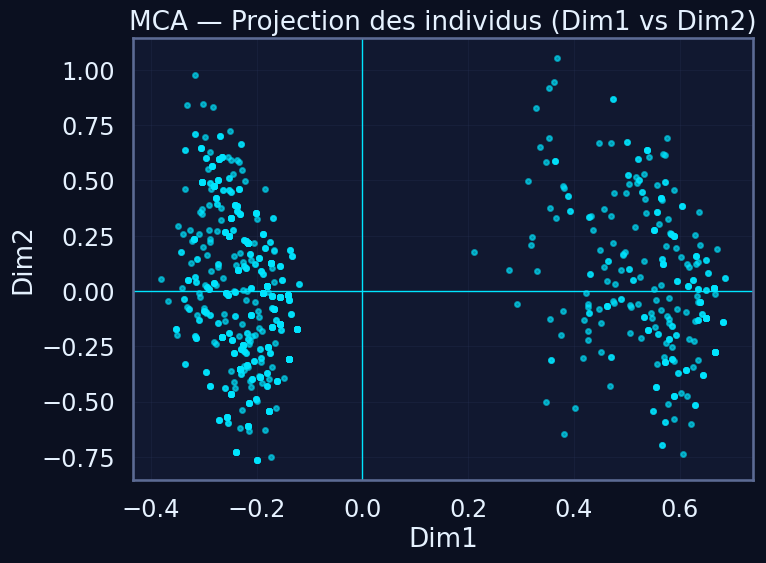

In [31]:
coords_ind = mca.row_coordinates(X_cat)

# Échantillonnage si trop de points
MAX_POINTS = 1200
if len(coords_ind) > MAX_POINTS:
    coords_plot = coords_ind.sample(MAX_POINTS, random_state=42)
else:
    coords_plot = coords_ind

plt.figure(figsize=(8, 6))
plt.scatter(coords_plot[0], coords_plot[1], s=12, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("MCA — Projection des individus (Dim1 vs Dim2)")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


###  Visualisation des modalités (categories)

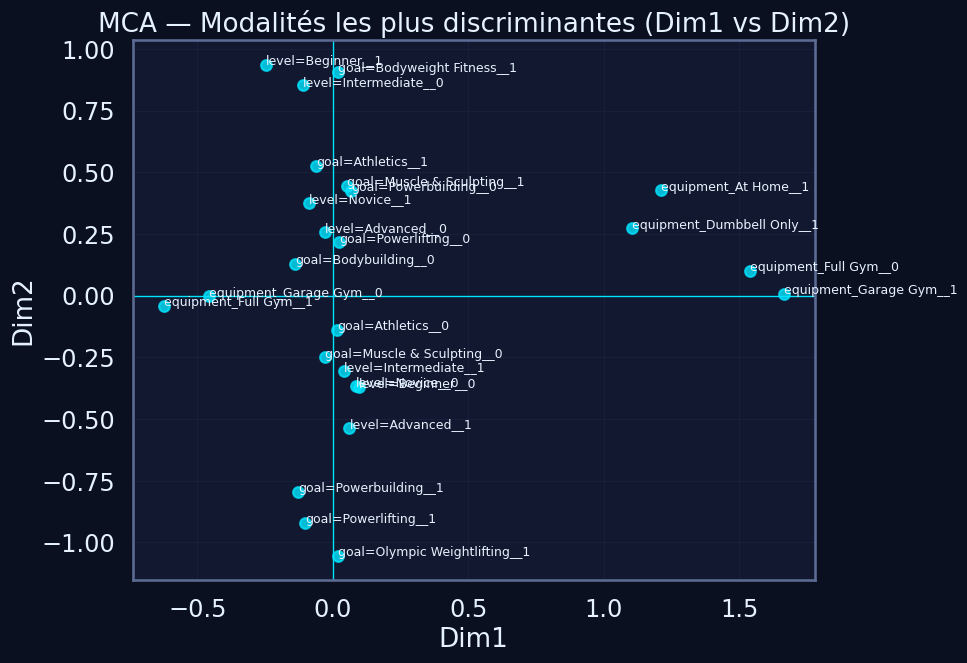

In [32]:
coords_mod = mca.column_coordinates(X_cat)

# On affiche les modalités les plus éloignées (plus informatives visuellement)
coords_mod["dist"] = np.sqrt(coords_mod[0]**2 + coords_mod[1]**2)
top_mod = coords_mod.sort_values("dist", ascending=False).head(25)

plt.figure(figsize=(10, 7))
plt.scatter(top_mod[0], top_mod[1], s=60, alpha=0.8)

for idx, row in top_mod.iterrows():
    plt.text(row[0], row[1], idx, fontsize=9)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("MCA — Modalités les plus discriminantes (Dim1 vs Dim2)")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Contributions des modalités aux axes principaux

In [ ]:
# Récupération des contributions colonnes/modalités
try:
    contrib = mca.column_contributions_  # ✅ nouvelle propriété (DataFrame)
except AttributeError:
    raise AttributeError("La propriété 'column_contributions_' est absente de cet objet MCA (vérifie ta version de prince).")

# Vérification du format
display(contrib.head())

# Top 10 des modalités les plus contributrices sur la première dimension
if 0 in contrib.columns:
    contrib["Dim1_abs"] = contrib[0].abs()
    top_contrib = contrib.sort_values("Dim1_abs", ascending=False).head(10)
    display(top_contrib)
else:
    print("Aucune dimension 0 trouvée dans les contributions.")


,0,1,2,3,4
equipment_At Home__0,0.001707,0.000228,0.000099,0.000070,0.007145
equipment_At Home__1,0.035555,0.004745,0.002072,0.001468,0.148838
equipment_Dumbbell Only__0,0.000468,0.000031,0.000013,0.000904,0.003015
equipment_Dumbbell Only__1,0.017135,0.001126,0.000483,0.033145,0.110506
equipment_Full Gym__0,0.362061,0.001620,0.003148,0.007558,0.001410


,0,1,2,3,4,Dim1_abs
equipment_Full Gym__0,0.362061,0.001620,0.003148,0.007558,0.001410,0.362061
equipment_Garage Gym__1,0.316538,0.000007,0.006064,0.000392,0.063609,0.316538
equipment_Full Gym__1,0.146940,0.000658,0.001278,0.003068,0.000572,0.146940
equipment_Garage Gym__0,0.087176,0.000002,0.001670,0.000108,0.017518,0.087176
equipment_At Home__1,0.035555,0.004745,0.002072,0.001468,0.148838,0.035555
equipment_Dumbbell Only__1,0.017135,0.001126,0.000483,0.033145,0.110506,0.017135
level=Beginner__1,0.009083,0.141378,0.028489,0.038629,0.064680,0.009083
level=Beginner__0,0.003597,0.055989,0.011282,0.015298,0.025615,0.003597
goal=Bodybuilding__0,0.003425,0.003127,0.096598,0.031117,0.102821,0.003425
goal=Powerbuilding__1,0.003028,0.124855,0.070609,0.034576,0.003618,0.003028


C:\Users\fback\AppData\Local\Temp\ipykernel_21544\4132163631.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


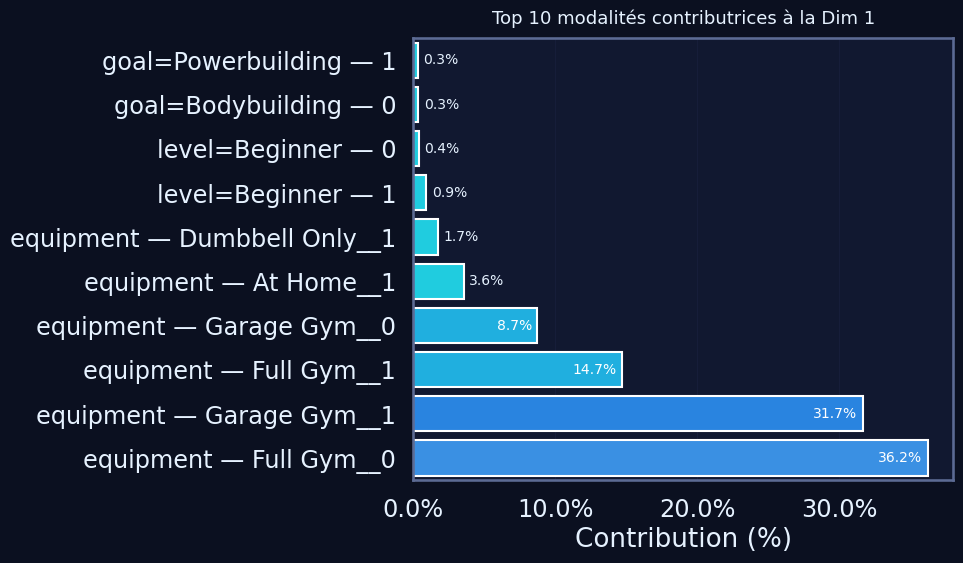

In [35]:
# Fallback palette si besoin
try:
    _ = palette_trainme
except NameError:
    sns.set_style("ticks"); sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")

contrib = mca.column_contributions_
assert 0 in contrib.columns, "La dimension 0 (Dim 1) est absente de column_contributions_."

dfc = contrib.copy()
dfc["Dim1_abs"] = dfc[0].abs()

# Index → var/mod (gère MultiIndex et index simples)
if isinstance(dfc.index, pd.MultiIndex):
    dfc = dfc.reset_index().rename(columns={"level_0": "var", "level_1": "mod"})
else:
    idx = dfc.index.astype(str)
    parts = pd.DataFrame(idx.str.split(r"__|_", n=1).tolist(), columns=["var", "mod"])
    parts["var"] = parts["var"].fillna("")
    # Patch: fournir une Series alignée à fillna
    idx_series = pd.Series(idx, index=parts.index)
    parts["mod"] = parts["mod"].fillna(idx_series)           # ← corrige le TypeError
    dfc = pd.concat([dfc.reset_index(drop=True), parts], axis=1)

# Labels compacts (wrap si trop long)
def make_label(v, m, width=28):
    lab = f"{str(v).strip()} — {str(m).strip()}"
    return "\n".join(textwrap.wrap(lab, width=width)) if len(lab) > width else lab

dfc["label"] = [make_label(v, m) for v, m in zip(dfc["var"], dfc["mod"])]

# Top 10
top_contrib = dfc.sort_values("Dim1_abs", ascending=False).head(10).copy()

# % si 0–1, sinon absolu
is_prop = top_contrib["Dim1_abs"].max() <= 1.0
top_contrib["plot_value"] = top_contrib["Dim1_abs"] * (100.0 if is_prop else 1.0)
x_label = "Contribution (%)" if is_prop else "Contribution (abs.)"

# Palette par variable
vars_unique = top_contrib["var"].unique().tolist()
palette_map = {v: palette_trainme[i % len(palette_trainme)] for i, v in enumerate(vars_unique)}
bar_colors = top_contrib["var"].map(palette_map)

# Ordre: petit → grand pour afficher le plus grand en haut
order_y = top_contrib.sort_values("plot_value")["label"]

plt.figure(figsize=(10, 6))
# seaborn v0.14+: éviter le warning "palette sans hue" → utiliser color=None + palette via list colors
ax = sns.barplot(
    data=top_contrib,
    x="plot_value",
    y="label",
    order=order_y,
    palette=bar_colors.tolist()  # passe explicitement une liste de couleurs
)

# Annotations intelligentes
xmax = ax.get_xlim()[1]
for y, val in zip(ax.get_yticks(), top_contrib.set_index("label").loc[order_y, "plot_value"]):
    txt = f"{val:.1f}%" if is_prop else f"{val:.3f}"
    if val > 0.18 * xmax:
        ax.text(val - 0.01 * xmax, y, txt, va="center", ha="right", fontsize=10, color="white")
    else:
        ax.text(val + 0.01 * xmax, y, txt, va="center", ha="left", fontsize=10)

ax.set_title("Top 10 modalités contributrices à la Dim 1", fontsize=13, pad=10)
ax.set_xlabel(x_label); ax.set_ylabel("")
if is_prop:
    ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## Détection d’anomalies et valeurs extrêmes

#### Objectif
Identifier les valeurs atypiques du dataset **program_summary.csv** susceptibles de perturber l’analyse
ou l’entraînement du modèle de génération (TrAIn.me), en distinguant :

- les outliers numériques (durée, temps par séance, volume d’exercices) ;
- les modalités catégorielles rares (équipement, objectifs, niveaux) ;
- les observations atypiques dans l’espace factoriel (ACM/MCA), indicatives de combinaisons de modalités peu fréquentes.

Cette étape permet de décider s’il faut filtrer, plafonner ou pondérer certaines observations.


#### Interprétation attendue
À l’issue de cette section, on devra :
- quantifier les outliers numériques (IQR puis Z-score en complément) ;
- visualiser les variables les plus touchées ;
- identifier les catégories rares (faible fréquence) ;
- repérer les programmes “atypiques” dans l’espace MCA (distance élevée), souvent associés à des combinaisons de modalités inhabituelles ;
- proposer un traitement recommandé (conserver, filtrer, cap/clipping, pondération) en gardant une logique métier.


### Imports & sélection des colonnes pertinentes

In [36]:
# Colonnes numériques et catégorielles d'intérêt
NUM_COLS = [c for c in ["program_length", "time_per_workout", "total_exercises"] if c in df.columns]
CAT_COLS = [c for c in ["equipment", "level", "goal"] if c in df.columns]

print("Numériques :", NUM_COLS)
print("Catégorielles :", CAT_COLS)

# Copie de travail
df_anom = df.copy()


Numériques : ['program_length', 'time_per_workout', 'total_exercises']
Catégorielles : ['equipment', 'level', 'goal']


### Méthode IQR (Interquartile Range) — Outliers numériques

In [37]:
def iqr_outliers(df_in: pd.DataFrame, col: str, k: float = 1.5):
    s = df_in[col].dropna()
    if s.empty:
        return pd.DataFrame(index=df_in.index, data={col: False}), None

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr

    mask = (df_in[col] < low) | (df_in[col] > high)
    bounds = {"Q1": q1, "Q3": q3, "IQR": iqr, "low": low, "high": high}
    return mask, bounds

iqr_summary = []
iqr_masks = {}

for col in NUM_COLS:
    mask, bounds = iqr_outliers(df_anom, col, k=1.5)
    iqr_masks[col] = mask
    n_out = int(mask.sum())
    pct_out = (n_out / len(df_anom)) * 100
    iqr_summary.append({
        "variable": col,
        "outliers_count": n_out,
        "outliers_%": round(pct_out, 2),
        **(bounds if bounds else {})
    })

df_iqr = pd.DataFrame(iqr_summary).sort_values("outliers_count", ascending=False)
display(df_iqr)


,variable,outliers_count,outliers_%,Q1,Q3,IQR,low,high
2,total_exercises,85,3.27,108.0,307.75,199.75,-191.625,607.375
1,time_per_workout,58,2.23,60.0,90.00,30.00,15.000,135.000
0,program_length,0,0.00,5.0,12.00,7.00,-5.500,22.500


### Visualisation : boxplots des variables les plus affectées

Variables les plus affectées (IQR) : ['total_exercises', 'time_per_workout']


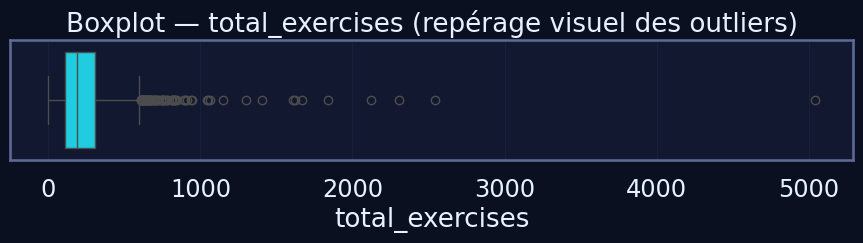

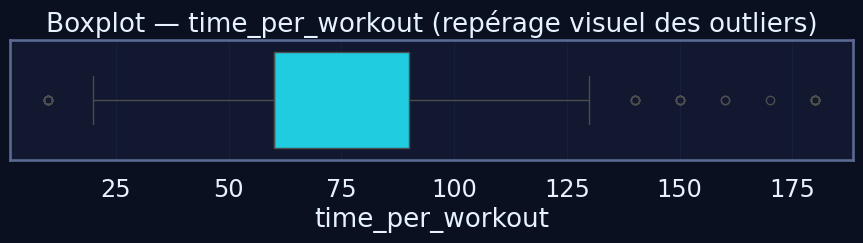

In [38]:
if not df_iqr.empty:
    # On prend les 2 variables avec le plus d'outliers IQR (souvent total_exercises + time_per_workout)
    top_vars = df_iqr.sort_values("outliers_count", ascending=False)["variable"].head(2).tolist()
else:
    top_vars = []

print("Variables les plus affectées (IQR) :", top_vars)

for col in top_vars:
    plt.figure(figsize=(9, 2.8))
    sns.boxplot(x=df_anom[col].dropna())
    plt.title(f"Boxplot — {col} (repérage visuel des outliers)")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Z-Score complémentaire (|Z| > 3)

In [39]:
z_summary = []

for col in NUM_COLS:
    s = df_anom[col].astype(float)
    mean = s.mean()
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        continue

    z = (s - mean) / std
    mask_z = z.abs() > 3
    n_out = int(mask_z.sum())
    pct_out = (n_out / len(df_anom)) * 100

    z_summary.append({
        "variable": col,
        "z_outliers_count": n_out,
        "z_outliers_%": round(pct_out, 2),
        "mean": round(mean, 3),
        "std": round(std, 3)
    })

df_z = pd.DataFrame(z_summary).sort_values("z_outliers_count", ascending=False)
display(df_z)


,variable,z_outliers_count,z_outliers_%,mean,std
1,time_per_workout,22,0.85,69.035,24.390
2,total_exercises,20,0.77,232.884,208.084
0,program_length,0,0.00,8.812,4.185


### Modalités rares (catégorielles) — détection simple

In [ ]:
cat_cols = [c for c in ["level", "equipment", "goals"] if c in df.columns]

rare_rows = []
threshold_ratio = 0.01   # <1% de fréquence
min_count = 5            # ou moins de 5 occurrences absolues

for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    total = len(df)
    rare = vc[(vc/total < threshold_ratio) | (vc < min_count)]
    if not rare.empty:
        tmp = (rare.to_frame("count")
                    .assign(ratio=lambda x: (100 * x["count"]/total).round(2))
                    .reset_index()
                    .rename(columns={"index": "modality"}))
        tmp.insert(0, "variable", c)
        rare_rows.append(tmp)

if rare_rows:
    rare_df = pd.concat(rare_rows, ignore_index=True).sort_values(["variable", "ratio"])
    display(rare_df.head(20))
else:
    print("ℹAucune modalité rare selon les seuils définis.")


,variable,level,count,ratio,equipment
28,equipment,NaN,1,0.04,NaN
23,level,"['Novice', 'Advanced']",1,0.04,NaN
24,level,"['Advanced', 'Intermediate', 'Beginner', 'Novi...",1,0.04,NaN
25,level,"['Beginner', 'Novice', 'Advanced', 'Intermedia...",1,0.04,NaN
26,level,"['Beginner', 'Intermediate', 'Advanced']",1,0.04,NaN
27,level,"['Intermediate', 'Advanced', 'Beginner']",1,0.04,NaN
19,level,"['Intermediate', 'Advanced', 'Beginner', 'Novi...",2,0.08,NaN
20,level,"['Novice', 'Intermediate', 'Beginner', 'Advanc...",2,0.08,NaN
21,level,"['Intermediate', 'Advanced', 'Novice', 'Beginn...",2,0.08,NaN
22,level,"['Beginner', 'Intermediate', 'Advanced', 'Novi...",2,0.08,NaN


### Observations atypiques via l'espace ACM (MCA)
- On mesure 'l'éloignement' dans le plan factoriel (Dim1..Dim3)
- Les points très éloignés = combinaisons de catégories peu communes

In [42]:
# Cette cellule suppose que tu as déjà :
# - X_cat : matrice one-hot utilisée pour MCA
# - mca   : modèle prince.MCA entraîné

if "mca" in globals() and "X_cat" in globals():
    coords = mca.row_coordinates(X_cat).copy()
    coords.columns = [f"Dim{i+1}" for i in range(coords.shape[1])]

    # Distance à l'origine sur Dim1 & Dim2 (suffisant pour repérer les atypiques)
    coords["dist_12"] = np.sqrt(coords["Dim1"]**2 + coords["Dim2"]**2)

    # Top N atypiques
    TOP_ATYP = 15
    idx_atyp = coords.sort_values("dist_12", ascending=False).head(TOP_ATYP).index

    df_atyp = df_anom.loc[idx_atyp, ["title", "equipment", "program_length", "time_per_workout", "total_exercises"]].copy()

    # Ajout d’un résumé des modalités (level/goal) lisible
    if "level" in df_anom.columns:
        df_atyp["level"] = df_anom.loc[idx_atyp, "level"].apply(safe_parse_list).apply(lambda x: ", ".join(x))
    if "goal" in df_anom.columns:
        df_atyp["goal"] = df_anom.loc[idx_atyp, "goal"].apply(safe_parse_list).apply(lambda x: ", ".join(x))

    df_atyp["dist_mca_dim1_2"] = coords.loc[idx_atyp, "dist_12"].values

    print("Programmes les plus atypiques (espace MCA Dim1 & Dim2)")
    display(df_atyp.sort_values("dist_mca_dim1_2", ascending=False))

else:
    print("Variables 'mca' et/ou 'X_cat' non trouvées dans le notebook.")
    print("Exécute d’abord la section 3.7.5 (Analyse multivariée ACM/MCA), puis relance cette cellule.")


Programmes les plus atypiques (espace MCA Dim1 & Dim2)


,title,equipment,program_length,time_per_workout,total_exercises,level,goal,dist_mca_dim1_2
657,Chat Gpt Full Body Workout,At Home,12.0,30.0,252,"Beginner, Novice","Bodyweight Fitness, Bodybuilding, Athletics, M...",1.115766
2536,fbgfgnfnfdn,Garage Gym,1.0,40.0,12,"Beginner, Novice","Bodyweight Fitness, Bodybuilding, Athletics, M...",1.102989
363,BEEJ (1),Full Gym,18.0,50.0,503,"Beginner, Novice","Athletics, Muscle & Sculpting, Bodyweight Fitness",1.026260
1110,Home Fat Loss Program,At Home,4.0,30.0,60,Beginner,"Bodyweight Fitness, Muscle & Sculpting, Athletics",1.013031
843,Feather mark 1,At Home,12.0,60.0,468,Beginner,"Bodyweight Fitness, Muscle & Sculpting, Athletics",1.013031
1836,Pure AesthetiX: Push Pull Leg Arm Hypertrophy ...,Garage Gym,12.0,120.0,360,"Beginner, Novice","Bodyweight Fitness, Muscle & Sculpting",1.010826
2557,oscars big hard pump,Garage Gym,12.0,100.0,276,Beginner,"Bodyweight Fitness, Muscle & Sculpting, Athletics",1.006941
1091,Hezbollah Destroyer,Garage Gym,12.0,60.0,348,"Beginner, Novice","Athletics, Bodyweight Fitness",0.991130
1389,Lucky 5,Garage Gym,5.0,60.0,80,"Beginner, Novice","Athletics, Bodyweight Fitness",0.991130
1421,Malone Beginner Strength,At Home,8.0,30.0,120,"Beginner, Novice","Athletics, Bodybuilding, Bodyweight Fitness",0.983562
